# Tarea 1 — Árboles de Decisión: **CART**



## ¿Qué es un Árbol de Decisión?

Modelo de **aprendizaje supervisado** con estructura jerárquica de nodos: cada **nodo interno** hace
una *pregunta* sobre un atributo, cada **rama** es una respuesta, y cada **hoja** es la predicción.
El entrenamiento elige en cada nodo el atributo que mejor **separa** los datos según un criterio de
pureza. Los tres algoritmos de la familia (Grupo B) se diferencian así:

| Algoritmo | Año | Autor | Criterio | División | Objetivo |
|-----------|-----|-------|----------|----------|----------|
| **ID3**   | 1986 | Quinlan | Ganancia de Información (Entropía) | Multi-vía | Categórico |
| **CART**  | 1984 | Breiman et al. | Índice Gini / MSE | Binaria | Categórico o numérico |
| **CHAID** | 1980 | Kass | Chi-cuadrado (χ²) | Multi-vía (con fusión) | Categórico |


## Ficha técnica

### Descripción
**CART (Classification And Regression Trees)** construye árboles **estrictamente binarios** (dos
ramas por nodo). Para **clasificación** usa el **índice de Gini**; para **regresión** usa el **MSE**.
Incluye **poda por costo-complejidad** para controlar el sobreajuste. Es el algoritmo que implementa
`scikit-learn` en `DecisionTreeClassifier` / `DecisionTreeRegressor`.

### Tipo de Modelo
- **Método de aprendizaje:** Supervisado (clasificación **y** regresión)
- **Por Parámetros:** No paramétrico
- **Datos de aprendizaje:** Offline / Batch
- **Resultado del entrenamiento:** Basado en Modelo (árbol binario)

### Algoritmo de Entrenamiento
Partición binaria recursiva minimizando la **impureza de Gini** (clasificación) o el **MSE**
(regresión), seguida de **poda por costo-complejidad**:

$$Gini(S) = 1 - \sum_{i=1}^{c} p_i^{2}$$

### Supuestos y Restricciones
- Maneja variables **numéricas y categóricas**; objetivo **categórico o continuo**.
- Divisiones **solo binarias**.
- Propenso al **sobreajuste** sin poda/límite de profundidad.
- **Inestable** (base de *ensembles* como Random Forest).
- Fronteras de decisión **ortogonales** a los ejes.


## 1. Publicación que propuso el algoritmo
> **Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*. Wadsworth.**

Libro seminal que unificó clasificación y regresión bajo árboles binarios y formalizó la poda por costo-complejidad.

```bibtex
@book{breiman1984classification,
  title={Classification and Regression Trees},
  author={Breiman, Leo and Friedman, Jerome H and Olshen, Richard A and Stone, Charles J},
  year={1984}, publisher={Wadsworth International Group}
}
```
**APA:** Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and regression trees*. Wadsworth.

## 2. Cómo funciona (paso a paso)
1. Para cada atributo y cada **punto de corte binario**, evaluar la impureza de Gini (o MSE).
2. Elegir la **división binaria** que **más reduce** la impureza.
3. Dividir el nodo en dos y **repetir recursivamente**.
4. Detenerse por criterios de parada (profundidad, mínimo de muestras, impureza).
5. **Podar** con costo-complejidad para mejorar la generalización.

## 3. Tipos de entrada
- Predictoras **numéricas y/o categóricas**; objetivo **categórico o continuo**.
- No requiere normalización.

## 4. Casos de uso
- **Scoring de crédito**, detección de fraude, *churn*.
- Base de **Random Forest** y **Gradient Boosting (XGBoost, LightGBM)**.
- Regresión interpretable (precios, demanda).

## 5. Source Code en Python
`scikit-learn` (que implementa CART) sobre el dataset **Iris**.


In [ ]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report

iris = load_iris(); X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# criterion="gini" -> exactamente el criterio de CART
cart = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
cart.fit(X_train, y_train)

y_pred = cart.predict(X_test)
print(f"Accuracy en test: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Accuracy en test: 0.978

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [ ]:
# ------- Reglas del árbol en texto -------
print(export_text(cart, feature_names=list(iris.feature_names)))


|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: 2



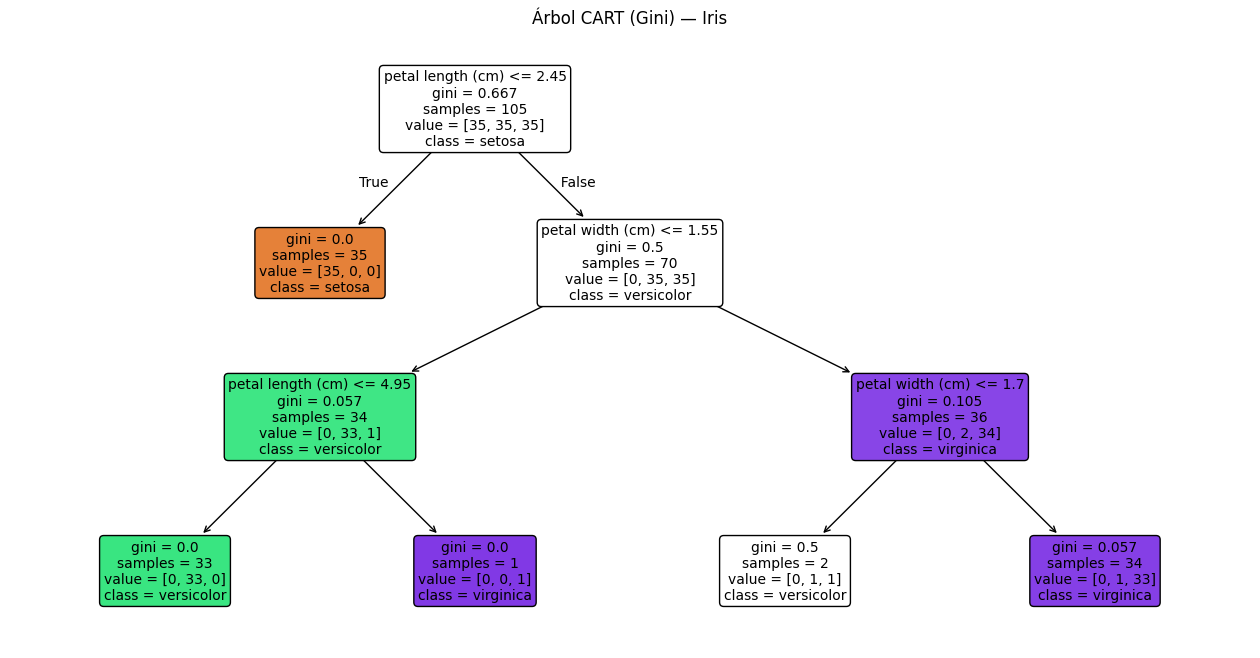


Importancia de variables:
petal length (cm)    0.550877
petal width (cm)     0.449123
sepal width (cm)     0.000000
sepal length (cm)    0.000000
dtype: float64


In [ ]:
# ------- Visualización gráfica del árbol CART -------
plt.figure(figsize=(16, 8))
plot_tree(cart, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=10)
plt.title("Árbol CART (Gini) — Iris"); plt.show()

importancias = pd.Series(cart.feature_importances_, index=iris.feature_names)
print("\nImportancia de variables:"); print(importancias.sort_values(ascending=False))


## 6. Matriz de confusión
Complemento a las métricas: dónde se equivoca el modelo en el conjunto de prueba.

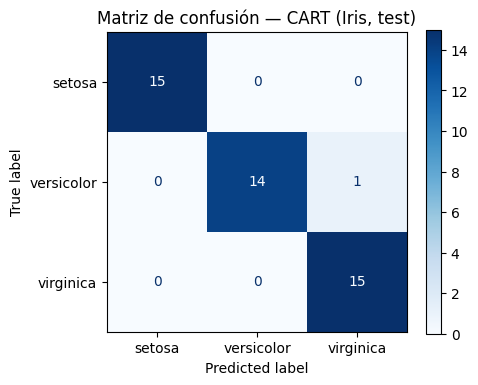

In [ ]:
# ------- Matriz de confusión en el conjunto de prueba -------
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=iris.target_names, cmap="Blues", ax=ax)
ax.set_title("Matriz de confusión — CART (Iris, test)")
plt.tight_layout(); plt.show()

## Conclusión
- Sobre **Iris (datos reales)**, CART con criterio **Gini** y `max_depth=3` alcanza una **alta exactitud** en el conjunto de prueba, apoyándose sobre todo en *petal length* y *petal width* (ver importancia de variables).
- Las **divisiones binarias** generan fronteras ortogonales a los ejes: el árbol es compacto y sus reglas (`export_text`) son fáciles de leer.
- La **matriz de confusión** muestra que *setosa* se separa perfectamente y que los pocos errores se concentran entre *versicolor* y *virginica*, las clases que se solapan.
- CART es la base de *ensembles* como **Random Forest** y **Gradient Boosting**; aquí lo usamos aislado y limitado en profundidad para mantener la interpretabilidad.

## Referencia
Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and regression trees*. Wadsworth.
